# **Support Vector Regression (SVR)**

So far, we have used **Support Vector Machines (SVM)** for **classification**, where the goal is to separate data into different classes.

However, SVM can also be used for **regression** problems. This variation is called **Support Vector Regression (SVR)**.

Unlike classification, where SVM finds the **best decision boundary** to separate classes, **SVR** finds the **best-fit line (or curve)** that predicts continuous numerical values while allowing a small margin of error.

Instead of minimizing the error for every data point, SVR tries to fit a function such that **most data points lie within a predefined margin**, known as the **epsilon tube**. Points that lie inside this margin are considered acceptable and do not contribute to the model's loss.

This approach makes SVR robust to small variations in the data while maintaining good generalization performance.


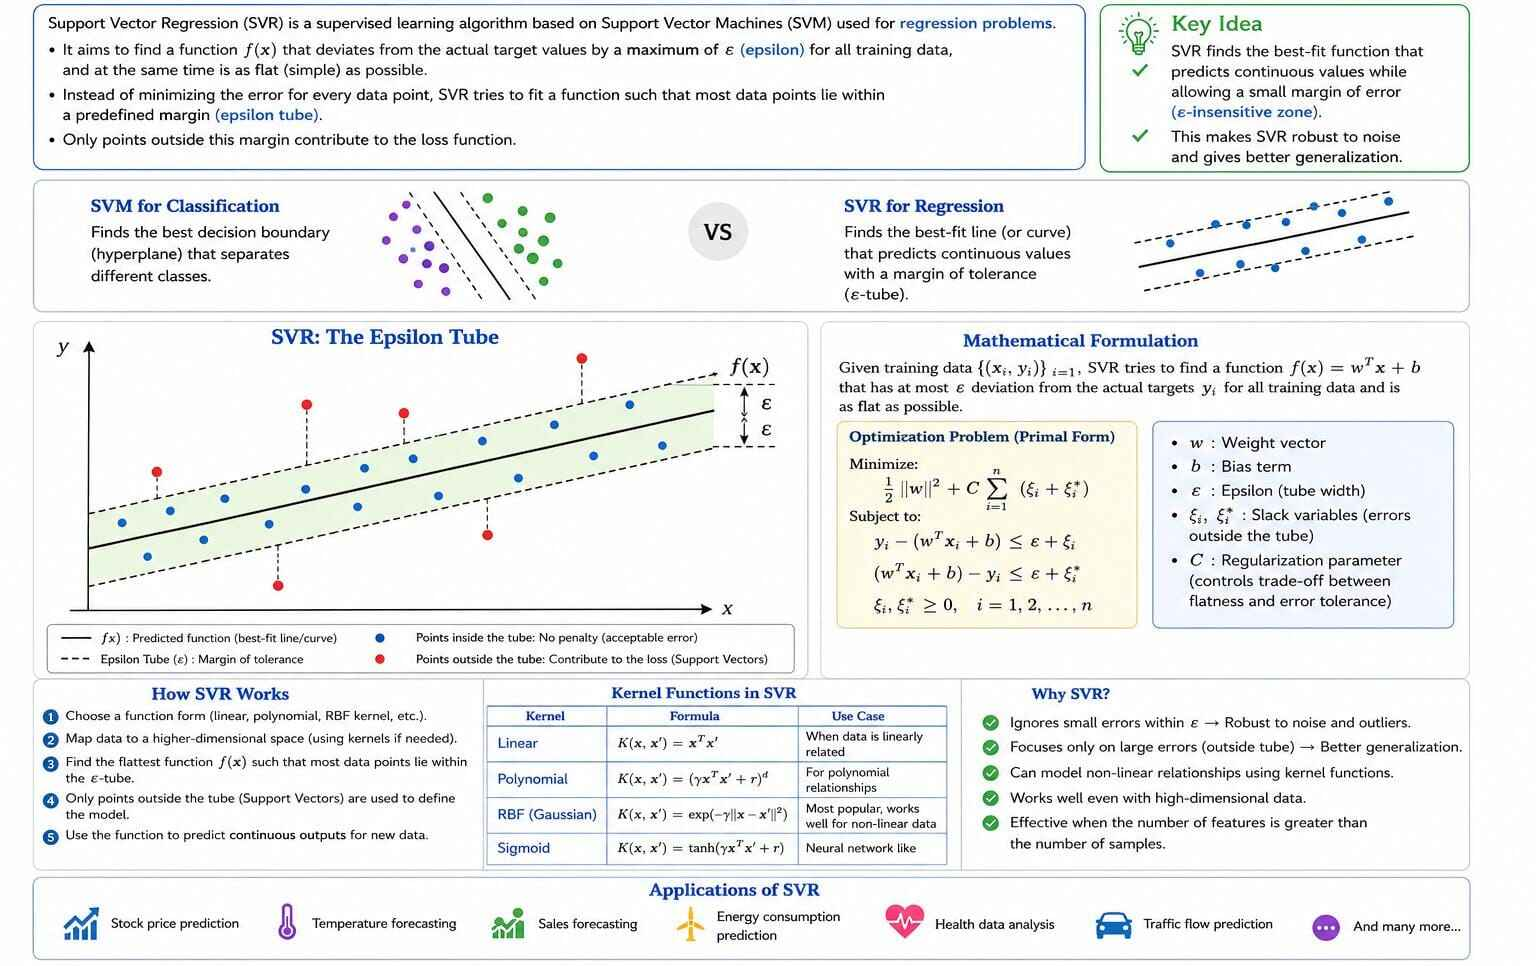

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.set_printoptions(threshold=200)
plt.rcParams['figure.figsize'] = (7, 5)
%matplotlib inline

## 2. Load the Dataset

We use the classic **Tips** dataset : `total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, `size`.

Since `seaborn.load_dataset()` needs an internet connection to fetch the CSV from GitHub, we add a small **fallback**: if the fetch fails (e.g. no internet / restricted network), we generate a synthetic dataset with the exact same columns and realistic value ranges, so the rest of the notebook still runs end-to-end regardless of your environment.

In [2]:
def load_tips_dataset(random_state=42):
    """Load the real seaborn 'tips' dataset; fall back to a synthetic
    but structurally identical dataset if there is no internet access."""
    try:
        data = sns.load_dataset('tips')
        if data is not None and len(data) > 0:
            print("Loaded the real 'tips' dataset from seaborn ({} rows).".format(len(data)))
            return data
    except Exception as e:
        print("Could not fetch 'tips' dataset online ({}).".format(type(e).__name__))


    print("Falling back to a synthetic 'tips'-like dataset with the same schema.")
    rng = np.random.RandomState(random_state)
    n = 244  # same size as the real tips dataset
    size = rng.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.05, 0.55, 0.15, 0.15, 0.06, 0.04])
    total_bill = np.round(8 + size * rng.uniform(3, 6, n) + rng.normal(0, 3, n), 2)
    total_bill = np.clip(total_bill, 3, 55)
    tip_pct = np.clip(rng.normal(0.16, 0.05, n), 0.05, 0.35)
    tip = np.round(total_bill * tip_pct, 2)
    sex = rng.choice(['Male', 'Female'], size=n, p=[0.64, 0.36])
    smoker = rng.choice(['No', 'Yes'], size=n, p=[0.62, 0.38])
    day = rng.choice(['Thur', 'Fri', 'Sat', 'Sun'], size=n, p=[0.25, 0.08, 0.36, 0.31])
    time = np.where(np.isin(day, ['Sat', 'Sun']), 'Dinner', rng.choice(['Lunch', 'Dinner'], size=n, p=[0.6, 0.4]))

    return pd.DataFrame({
        'total_bill': total_bill, 'tip': tip, 'sex': sex,
        'smoker': smoker, 'day': day, 'time': time, 'size': size
    })


df = load_tips_dataset()
df.head()

Loaded the real 'tips' dataset from seaborn (244 rows).


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## **Explore the Dataset**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


Let's check the categorical columns — this tells us which need **Label Encoding** (binary) vs **One-Hot Encoding** (more than 2 categories).

In [6]:
for col in ['sex', 'smoker', 'day', 'time']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- sex ---
sex
Male      157
Female     87
Name: count, dtype: int64

--- smoker ---
smoker
No     151
Yes     93
Name: count, dtype: int64

--- day ---
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

--- time ---
time
Dinner    176
Lunch      68
Name: count, dtype: int64



- `sex` → 2 categories (Male / Female) → **Label Encoding**
- `smoker` → 2 categories (Yes / No) → **Label Encoding**
- `time` → 2 categories (Lunch / Dinner) → **Label Encoding**
- `day` → 4 categories (Thur / Fri / Sat / Sun) → **One-Hot Encoding**

# **Visualizing the Dataset**

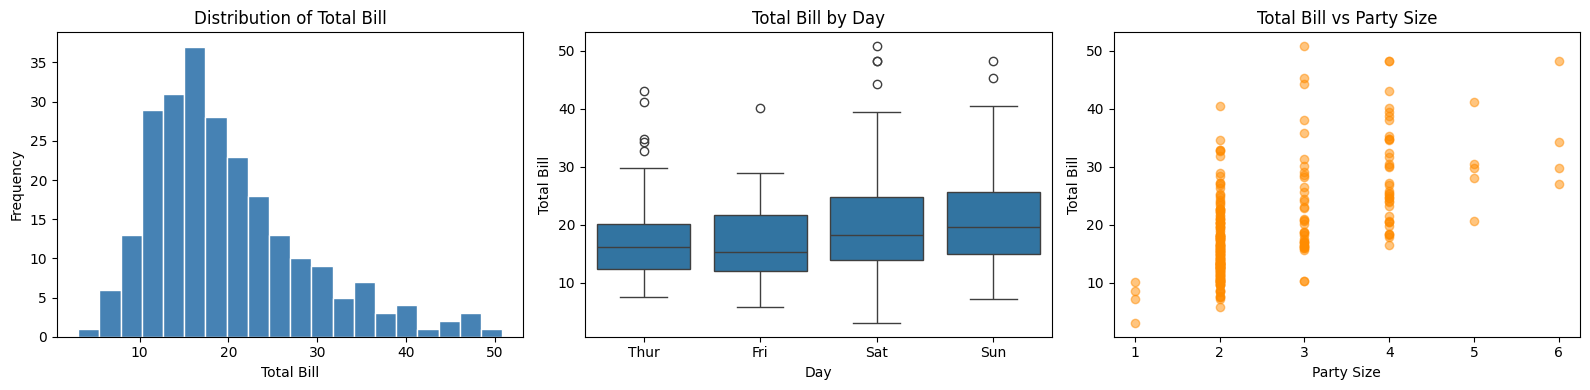

In [7]:
# Create a figure containing 1 row and 3 columns of subplots.
# figsize=(16,4) makes the figure wider so all plots fit nicely.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# =============================================================================
# Histogram
# =============================================================================
# A histogram shows how the values of a numerical feature are distributed.
# Each bar represents the number of observations that fall within a specific range.

axes[0].hist(
    df['total_bill'],      # Numerical feature to visualize
    bins=20,               # Divide the data into 20 intervals
    color='steelblue',     # Color of the bars
    edgecolor='white'      # White border around each bar
)

# Set title for the histogram
axes[0].set_title('Distribution of Total Bill')

# Label for x-axis
axes[0].set_xlabel('Total Bill')

# Label for y-axis
axes[0].set_ylabel('Frequency')


# =============================================================================
# Box Plot
# =============================================================================
# A box plot summarizes the distribution of data using:
# • Minimum
# • First Quartile (Q1)
# • Median
# • Third Quartile (Q3)
# • Maximum
# It also highlights outliers.

sns.boxplot(
    x='day',              # Categories on x-axis
    y='total_bill',       # Numerical variable on y-axis
    data=df,              # Dataset
    ax=axes[1]            # Draw on the second subplot
)

# Title
axes[1].set_title('Total Bill by Day')

# X-axis label
axes[1].set_xlabel('Day')

# Y-axis label
axes[1].set_ylabel('Total Bill')


# =============================================================================
# Scatter Plot
# =============================================================================
# A scatter plot shows the relationship between two numerical variables.
# Each point represents one observation.

axes[2].scatter(
    df['size'],           # Number of people in the party
    df['total_bill'],     # Total restaurant bill
    alpha=0.5,            # Makes points semi-transparent
    color='darkorange'    # Point color
)

# Title
axes[2].set_title('Total Bill vs Party Size')

# X-axis label
axes[2].set_xlabel('Party Size')

# Y-axis label
axes[2].set_ylabel('Total Bill')


# Automatically adjust spacing between plots
plt.tight_layout()

# Display all three plots
plt.show()

## **Observations**

### 1. Distribution of Total Bill (Histogram)

- The histogram shows the distribution of the **`total_bill`** feature.
- Most restaurant bills fall between **10 and 20**.
- The distribution is **positively (right) skewed**, meaning a few customers have much larger bills than the majority.
- Very high bills (above 40) occur less frequently.

**Conclusion:**

Most customers spend a moderate amount, while only a few customers spend significantly more.

---

### 2. Total Bill by Day (Box Plot)

The box plot compares the distribution of bills across different days.

From the plot we can observe:

- Saturday and Sunday generally have higher total bills.
- Weekend bills also have greater variability compared to weekdays.
- Several outliers are present, especially on weekends, indicating a few customers spent much more than average.
- Thursday and Friday have relatively smaller median bills.

**Conclusion:**

Customers tend to spend more on weekends, and spending is more variable during those days.

---

### 3. Total Bill vs Party Size (Scatter Plot)

The scatter plot illustrates the relationship between **party size** and **total bill**.

Observations:

- There is a **positive relationship** between party size and total bill.
- As the number of people increases, the total bill generally increases.
- However, customers with the same party size may still have different bills because ordering behavior varies.
- Most observations belong to parties of **2 to 4 people**, indicating these are the most common group sizes.

**Conclusion:**

Larger groups generally produce larger bills, although party size alone does not completely determine the total bill.

---

## **Overall Summary**

The three visualizations provide complementary insights into the dataset:

- **Histogram** reveals the overall distribution of restaurant bills.
- **Box Plot** compares spending behavior across different days and highlights outliers.
- **Scatter Plot** demonstrates the relationship between party size and total bill.


## **Independent (X) and Dependent (y) Features**

Our target (`y`) is `total_bill`. Everything else is a feature (`X`).

In [8]:
X = df.drop(columns=['total_bill'])
y = df['total_bill']

X.head()

,tip,sex,smoker,day,time,size
0,1.01,Female,No,Sun,Dinner,2
1,1.66,Male,No,Sun,Dinner,3
2,3.50,Male,No,Sun,Dinner,3
3,3.31,Male,No,Sun,Dinner,2
4,3.61,Female,No,Sun,Dinner,4


## **Train/Test Split — BEFORE Encoding**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=10
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
X_train.head()

X_train shape: (183, 6)
X_test shape : (61, 6)


,tip,sex,smoker,day,time,size
58,1.76,Male,Yes,Sat,Dinner,2
1,1.66,Male,No,Sun,Dinner,3
2,3.50,Male,No,Sun,Dinner,3
68,2.01,Male,No,Sat,Dinner,2
184,3.00,Male,Yes,Sun,Dinner,2


## Label Encoding for Binary Categorical Features

We fit a separate `LabelEncoder` for `sex`, `smoker`, and `time` **on the training data only**, then reuse the *same fitted* encoders to `transform` (not `fit_transform`) the test data — this is exactly how the transcript avoids data leakage.

In [10]:
# make explicit copies so we don't trigger SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_time = LabelEncoder()

# fit + transform on TRAIN
X_train['sex'] = le_sex.fit_transform(X_train['sex'])
X_train['smoker'] = le_smoker.fit_transform(X_train['smoker'])
X_train['time'] = le_time.fit_transform(X_train['time'])

# transform ONLY (no fit) on TEST — reuses the categories learned from train
X_test['sex'] = le_sex.transform(X_test['sex'])
X_test['smoker'] = le_smoker.transform(X_test['smoker'])
X_test['time'] = le_time.transform(X_test['time'])

X_train.head()

,tip,sex,smoker,day,time,size
58,1.76,1,1,Sat,0,2
1,1.66,1,0,Sun,0,3
2,3.50,1,0,Sun,0,3
68,2.01,1,0,Sat,0,2
184,3.00,1,1,Sun,0,2


## **One-Hot Encoding for `day` (4 Categories)**

We use `ColumnTransformer` + `OneHotEncoder(drop='first')` so that:
- Only the `day` column gets one-hot encoded (we look up its index in the feature order below)
- `drop='first'` removes one redundant column (the remaining columns can imply it — avoids the "dummy variable trap")
- `remainder='passthrough'` keeps all other already-encoded columns untouched

In [11]:
print("Column order:", list(X_train.columns))
day_index = list(X_train.columns).index('day')
print("Index of 'day' column:", day_index)

Column order: ['tip', 'sex', 'smoker', 'day', 'time', 'size']
Index of 'day' column: 3


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first'), [day_index])


    ],
    remainder='passthrough'
)

X_train_encoded = ct.fit_transform(X_train)
X_test_encoded = ct.transform(X_test)   # transform only — fitted on train

print("Encoded X_train shape:", X_train_encoded.shape)
X_train_encoded[:5]

Encoded X_train shape: (183, 8)


array([[1.  , 0.  , 0.  , 1.76, 1.  , 1.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 1.66, 1.  , 0.  , 0.  , 3.  ],
       [0.  , 1.  , 0.  , 3.5 , 1.  , 0.  , 0.  , 3.  ],
       [1.  , 0.  , 0.  , 2.01, 1.  , 0.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 3.  , 1.  , 1.  , 0.  , 2.  ]])

The first 3 columns are now the one-hot encoded `day` (Fri/Sat/Sun — `Thur` was dropped as the reference category), and the rest are the remaining passthrough columns (`sex`, `smoker`, `size`, `time` — in the original column order minus `day`).

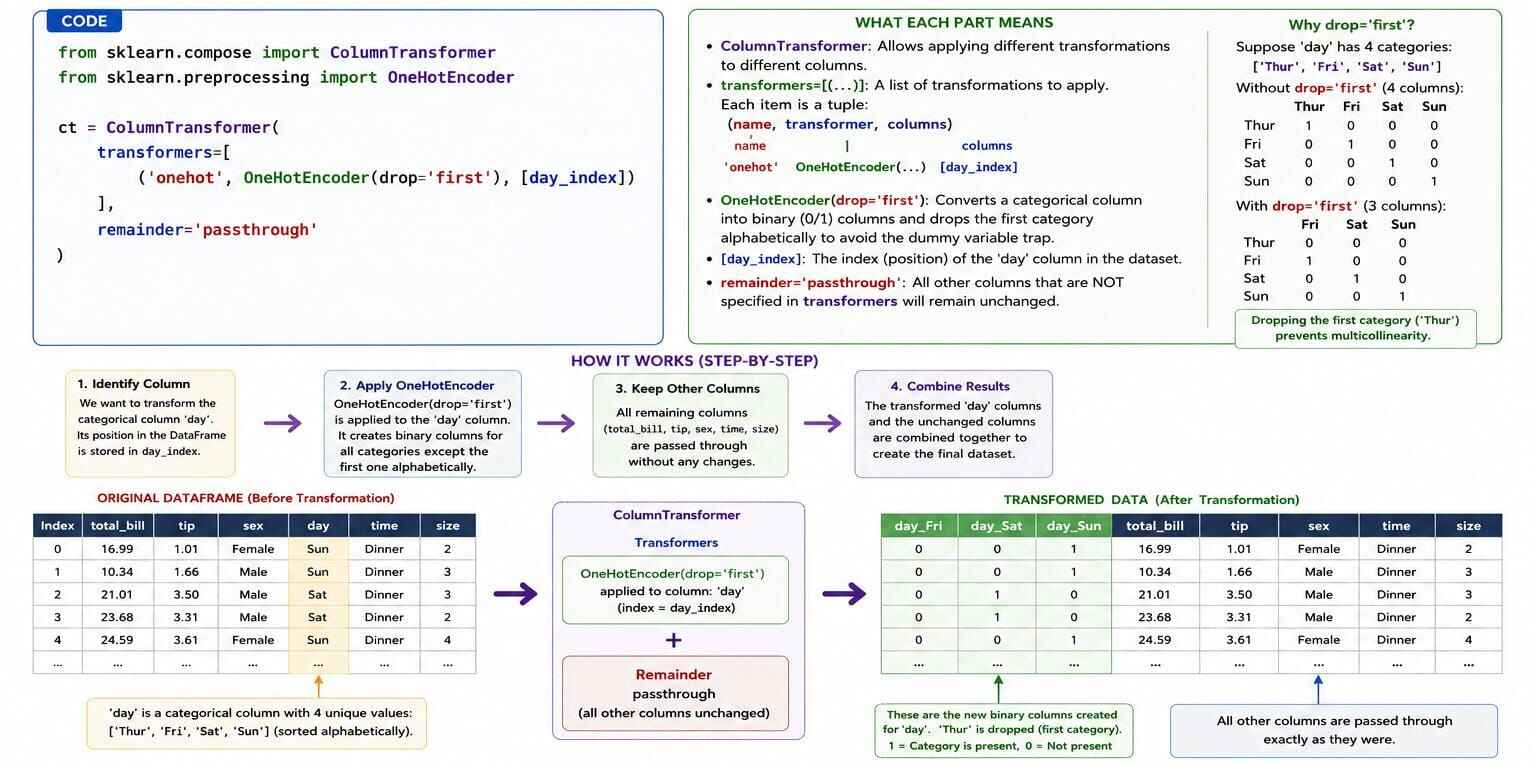

## **Baseline SVR Model (Unscaled Features)**


In [13]:
svr_baseline = SVR()
svr_baseline.fit(X_train_encoded, y_train)

y_pred_baseline = svr_baseline.predict(X_test_encoded)

r2_baseline = r2_score(y_test, y_pred_baseline)
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

print(f"Baseline SVR (unscaled) -> R2: {r2_baseline:.3f} | MAE: {mae_baseline:.3f}")

Baseline SVR (unscaled) -> R2: 0.460 | MAE: 4.149


## **Why Feature Scaling is Important for Support Vector Regression (SVR)**

Support Vector Regression (SVR) is a **distance-based machine learning algorithm**. By default, it uses the **Radial Basis Function (RBF) kernel**, which calculates the similarity between data points using the **Euclidean distance**:

$$
K(x, x') = \exp\left(-\gamma \|x - x'\|^2\right)
$$

Since the distance calculation depends on the magnitude of the feature values, **all features should be on a similar scale**.

### Why is scaling necessary?

In our dataset, different features have different ranges. For example:

- **`size`** ranges approximately from **1 to 6**
- **`tip`** ranges approximately from **1 to 10**
- **`total_bill`** ranges approximately from **3 to 50**

If the features are **not scaled**, the feature with the **largest numerical range** (such as `total_bill`) will dominate the distance calculation, while features with smaller ranges (such as `size`) will have much less influence.

As a result, the SVR model may:
- Give more importance to large-scale features.
- Learn an inaccurate decision function.
- Produce lower prediction accuracy.

### Solution: Standardization

To ensure that every feature contributes equally, we use **`StandardScaler`**.

`StandardScaler` transforms each feature so that:

- **Mean = 0**
- **Standard Deviation = 1**

This places all numerical features on the same scale, allowing SVR to compute distances fairly and learn a better regression function.

> **Important:** To prevent **data leakage**, we **fit** the `StandardScaler` **only on the training dataset** and then use the learned statistics (mean and standard deviation) to **transform both the training and test datasets**. The test data should never be used while fitting the scaler because it represents unseen data.

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

svr_scaled = SVR()
svr_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = svr_scaled.predict(X_test_scaled)

r2_scaled = r2_score(y_test, y_pred_scaled)
mae_scaled = mean_absolute_error(y_test, y_pred_scaled)

print(f"Baseline SVR (scaled)   -> R2: {r2_scaled:.3f} | MAE: {mae_scaled:.3f}")
print(f"Baseline SVR (unscaled) -> R2: {r2_baseline:.3f} | MAE: {mae_baseline:.3f}")

Baseline SVR (scaled)   -> R2: 0.370 | MAE: 4.826
Baseline SVR (unscaled) -> R2: 0.460 | MAE: 4.149


Compare the two R² scores above. **Lesson: always scale your features before using SVR/SVC with `rbf`, `poly`, or `sigmoid` kernels** — this single step is easy to forget but can make a real difference.

## **Hyperparameter Tuning using GridSearchCV**

Machine Learning models have **hyperparameters**, which are settings that control how the model learns from the data. Unlike model parameters (such as weights and bias), hyperparameters are **not learned during training**. Instead, they must be chosen before training begins.

For **Support Vector Regression (SVR)**, selecting appropriate hyperparameter values can significantly improve prediction performance.

In this notebook, we will use **GridSearchCV**, which automatically searches through multiple combinations of hyperparameters and selects the one that produces the best model.

### Hyperparameters we will tune

| Hyperparameter | Purpose |
|---------------|---------|
| **kernel** | Determines how the data is transformed before fitting the regression function. Different kernels help model different types of relationships. |
| **C** | Controls the trade-off between fitting the training data closely and maintaining a simpler model. Larger values reduce training error but may increase overfitting. |
| **gamma** | Determines how far the influence of each training example extends when using kernel functions like RBF and Polynomial. |
| **epsilon** | Defines the width of the epsilon tube. Errors inside this margin are ignored during training. |

### Why use GridSearchCV?

Instead of manually trying different hyperparameter values one by one, **GridSearchCV** automatically:

1. Creates every possible combination of the specified hyperparameters.
2. Trains an SVR model for each combination.
3. Evaluates each model using Cross-Validation.
4. Selects the combination with the highest validation score.
5. Retrains the model using the best hyperparameters.

Since SVR is sensitive to feature scales, we perform Grid Search on the **scaled training data**.

In [15]:
# Dictionary containing all hyperparameter values that GridSearchCV will test.
# Every possible combination of these values will be evaluated.

param_grid = {

    # Kernel function to use in SVR.
    # rbf    -> Best for most non-linear problems.
    # linear -> Fits a straight-line relationship.
    # poly   -> Fits polynomial relationships.
    'kernel': ['rbf', 'linear', 'poly'],

    # Regularization parameter.
    # Smaller C -> Simpler model (higher bias).
    # Larger C -> More flexible model (lower bias).
    'C': [0.1, 1, 10, 100],

    # Controls the influence of each training example.
    # Used only by kernel-based models such as RBF and Polynomial.
    'gamma': ['scale', 'auto', 0.1],

    # Width of the epsilon-insensitive tube.
    # Errors inside this margin are ignored.
    'epsilon': [0.1, 0.5, 1]
}


# Create the GridSearchCV object.
grid = GridSearchCV(

    # Base estimator
    estimator=SVR(),

    # Hyperparameter search space
    param_grid=param_grid,

    # After finding the best parameters,
    # retrain the model using the entire training dataset.
    refit=True,

    # Perform 5-fold Cross Validation.
    cv=5,

    # Use R² Score for model evaluation.
    scoring='r2',

    # Use all available CPU cores to speed up training.
    n_jobs=-1
)


# Train GridSearchCV.
# It will train many SVR models,
# evaluate every hyperparameter combination,
# and automatically select the best one.
grid.fit(X_train_scaled, y_train)


# Display the best hyperparameters.
print("Best Parameters:", grid.best_params_)

# Display the best average Cross Validation R² score.
print("Best CV R2 Score: {:.3f}".format(grid.best_score_))


Best Parameters: {'C': 1, 'epsilon': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV R2 Score: 0.525


## **How GridSearchCV Works**

Suppose we provide the following hyperparameter values:

- **Kernel:** 3 options
- **C:** 4 options
- **Gamma:** 3 options
- **Epsilon:** 3 options

The total number of hyperparameter combinations is:

$$
3 \times 4 \times 3 \times 3 = 108
$$

For each combination:

1. The training dataset is divided into **5 folds**.
2. The model is trained **5 times**, each time using a different validation fold.
3. The average **R² score** is calculated.
4. After evaluating all combinations, the best-performing hyperparameters are selected.
5. Finally, the model is retrained on the complete training dataset using the best hyperparameters.

This process helps us obtain a model with better generalization performance while reducing the risk of selecting suboptimal hyperparameter values manually.

In [16]:
# Use the best trained SVR model
# to make predictions on the scaled test dataset.
grid_predictions = grid.predict(X_test_scaled)


# Calculate the R² Score.
r2_tuned = r2_score(y_test, grid_predictions)

# Calculate the Mean Absolute Error.
mae_tuned = mean_absolute_error(y_test, grid_predictions)


# Display the model performance.
print(f"Tuned SVR -> R2: {r2_tuned:.3f} | MAE: {mae_tuned:.3f}")

Tuned SVR -> R2: 0.533 | MAE: 3.911


## **Observation**

After tuning the hyperparameters using **GridSearchCV**, the SVR model was evaluated on the test dataset.

The evaluation metrics are:

- **R² Score:** Indicates how well the model explains the variance in the target variable.
- **Mean Absolute Error (MAE):** Measures the average absolute difference between the actual and predicted values.

If the tuned model achieves:

- A **higher R² Score**, it explains more variability in the data.
- A **lower MAE**, its predictions are closer to the actual values.

Comparing these metrics with the baseline SVR model allows us to determine whether hyperparameter tuning has improved the model's predictive performance.

## **Cross-Validation**

The performance of a Machine Learning model can vary depending on how the training and testing datasets are split.

Since this dataset contains only **244 observations**, evaluating the model using a single train-test split may produce an optimistic or pessimistic estimate.

To obtain a more reliable estimate of model performance, we use **5-Fold Cross-Validation**.

### How 5-Fold Cross-Validation Works

1. The training dataset is divided into **5 equal folds**.
2. The model is trained on **4 folds**.
3. The remaining fold is used for validation.
4. This process repeats **5 times**, allowing every fold to serve as the validation set once.
5. Finally, the average R² Score across all folds is calculated.

The average Cross-Validation score provides a more stable estimate of how the model is expected to perform on unseen data.

In [17]:
# Retrieve the best SVR model found by GridSearchCV.
best_svr = grid.best_estimator_


# Evaluate the model using 5-fold Cross Validation.
cv_scores = cross_val_score(
    best_svr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)


# Display the R² score for each fold.
print("Cross-validation R2 scores:", np.round(cv_scores, 3))

# Display the mean and standard deviation.
print(f"Mean CV R2: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

Cross-validation R2 scores: [0.255 0.547 0.724 0.449 0.649]
Mean CV R2: 0.525 (+/- 0.164)


## **Observation**

The Cross-Validation results provide the R² Score for each of the five folds, along with the average score.

- A **high mean R² Score** indicates that the model performs well across different subsets of the training data.
- A **low standard deviation** suggests that the model's performance is consistent and stable.
- A **high standard deviation** indicates that the model's performance varies considerably across different folds, which may suggest sensitivity to the training data.

Overall, Cross-Validation gives a more reliable estimate of the model's real-world performance than relying on a single train-test split.

## **Actual vs Predicted & Residual Plots**

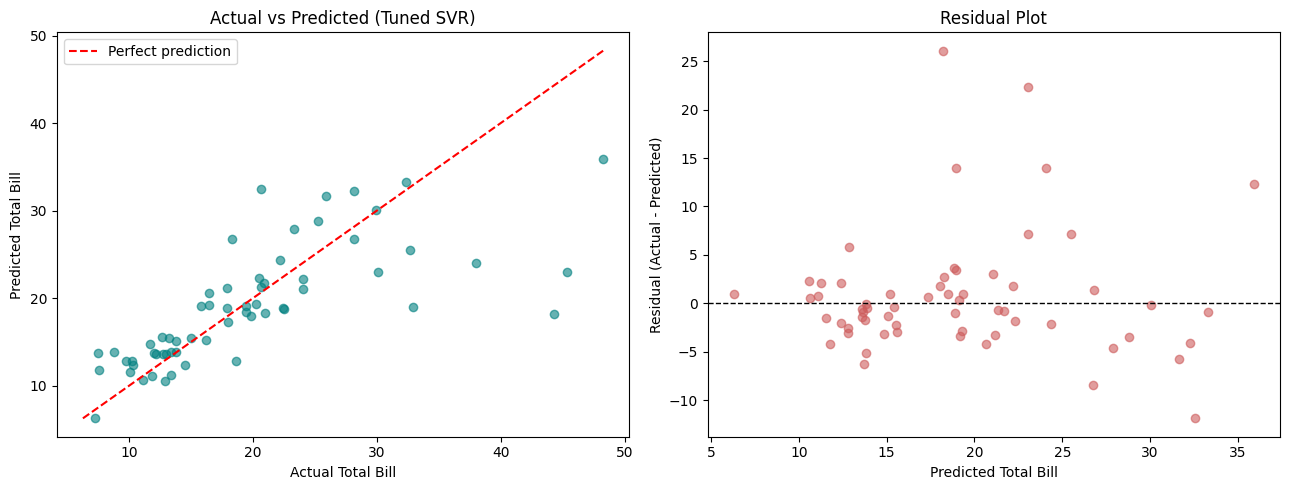

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, grid_predictions, alpha=0.6, color='teal')
lims = [min(y_test.min(), grid_predictions.min()), max(y_test.max(), grid_predictions.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Total Bill')
axes[0].set_ylabel('Predicted Total Bill')
axes[0].set_title('Actual vs Predicted (Tuned SVR)')
axes[0].legend()

# Residuals
residuals = y_test - grid_predictions
axes[1].scatter(grid_predictions, residuals, alpha=0.6, color='indianred')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted Total Bill')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

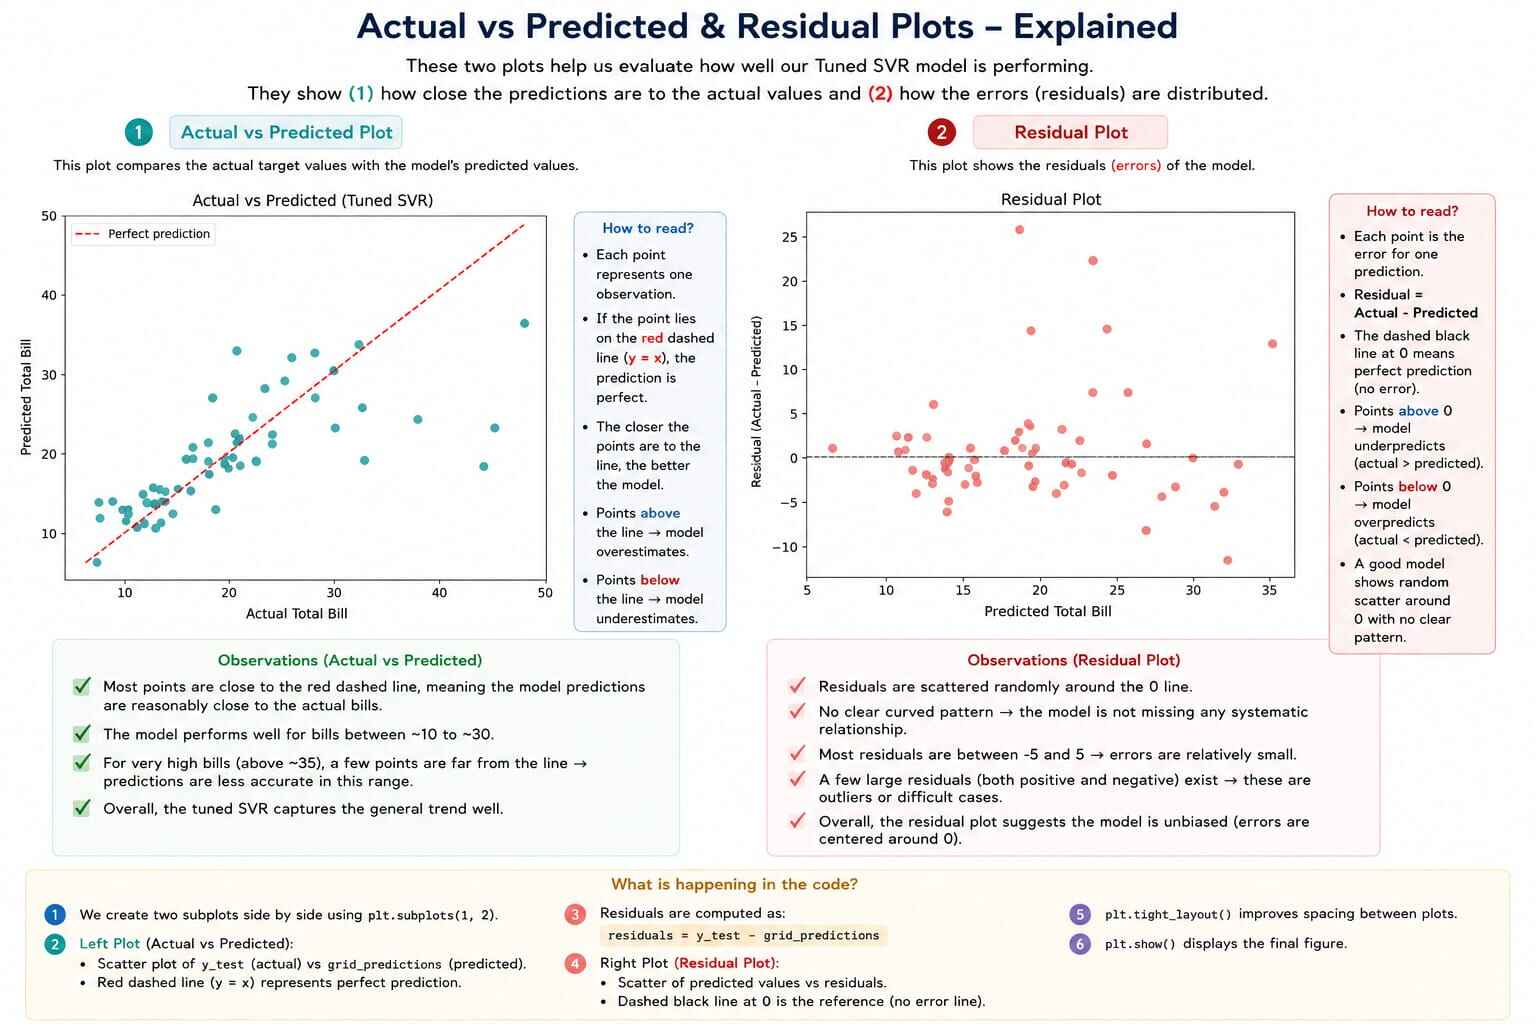

## **Final Comparison Table**

In [19]:
comparison = pd.DataFrame({
    'Model': ['SVR (unscaled, default params)', 'SVR (scaled, default params)', 'SVR (scaled, GridSearchCV tuned)'],
    'R2 Score': [r2_baseline, r2_scaled, r2_tuned],
    'MAE': [mae_baseline, mae_scaled, mae_tuned]
})
comparison

,Model,R2 Score,MAE
0,"SVR (unscaled, default params)",0.460281,4.148642
1,"SVR (scaled, default params)",0.370302,4.825935
2,"SVR (scaled, GridSearchCV tuned)",0.532893,3.910514


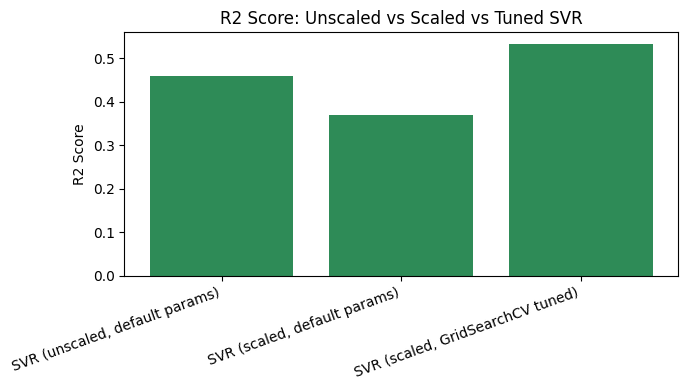

In [20]:
plt.figure(figsize=(7, 4))
plt.bar(comparison['Model'], comparison['R2 Score'], color='seagreen')
plt.ylabel('R2 Score')
plt.title('R2 Score: Unscaled vs Scaled vs Tuned SVR')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

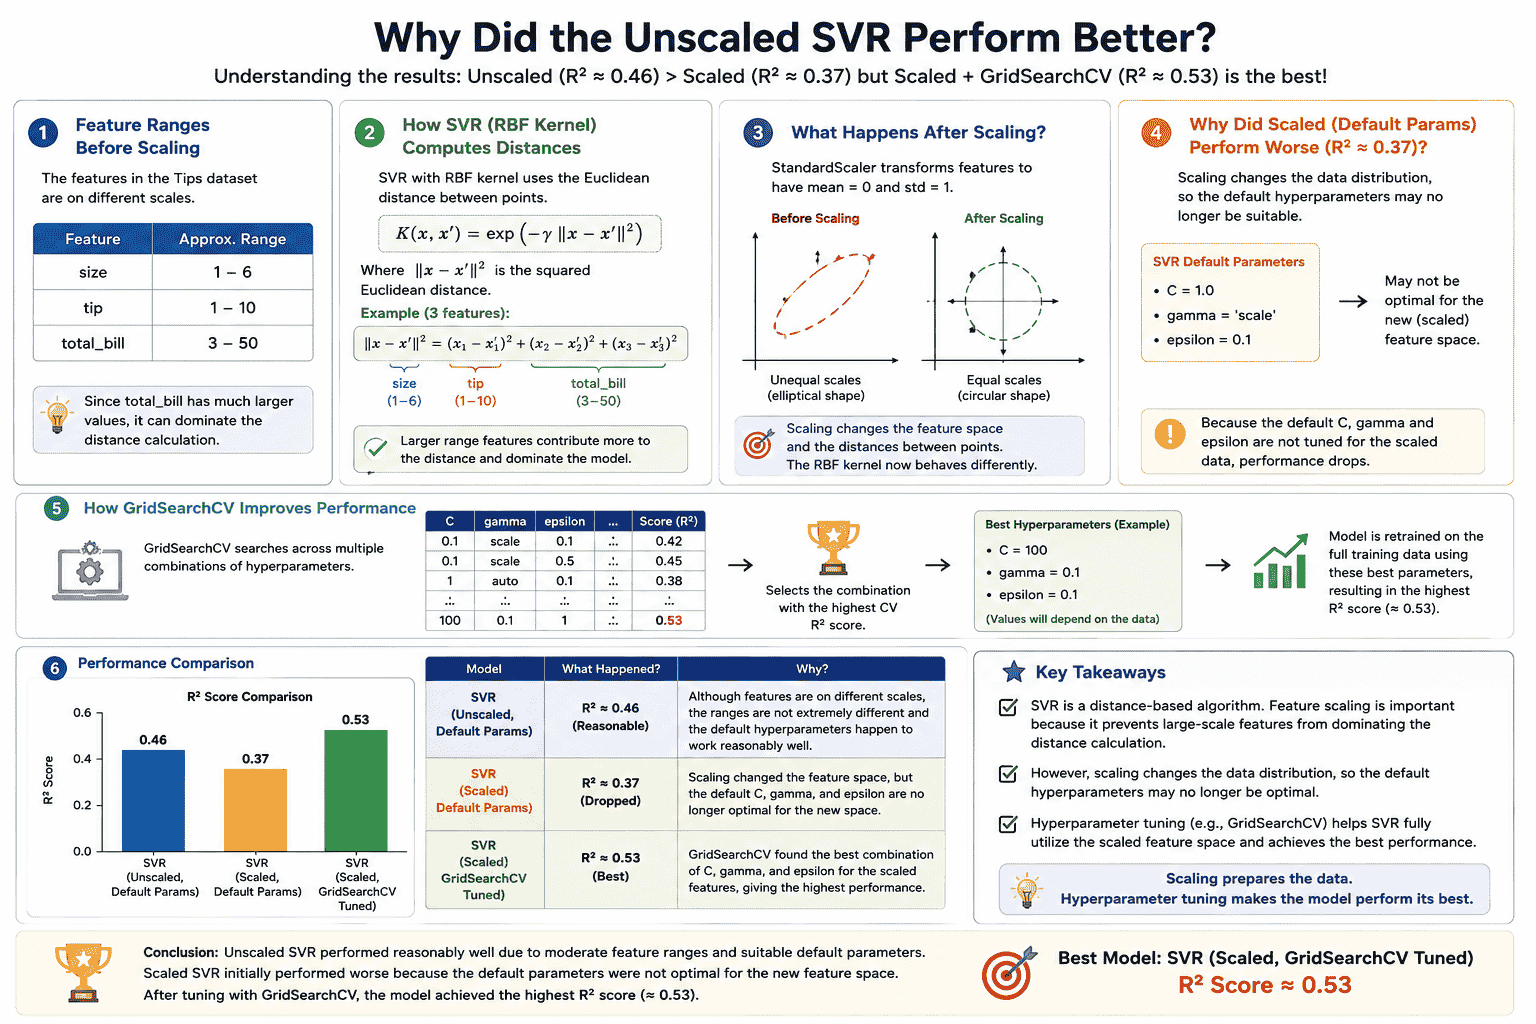

In [22]:
import pandas as pd

# New unseen customer
new_data = pd.DataFrame({
    'tip': [4.00],  # Added a sample tip value
    'sex': ['Male'],
    'smoker': ['No'], # Added smoker status
    'day': ['Sun'],
    'time': ['Dinner'],
    'size': [3]
})

# Step 1: Encode categorical features
# The ColumnTransformer 'ct' was designed to work on the original feature set (X) which included 'tip' and 'smoker'.
# 'ct' also expects 'day' to be one-hot encoded, and other features to pass through.
# However, 'ct' was defined to handle only the 'day' column for one-hot encoding.
# To correctly encode 'sex', 'smoker', 'day', 'time', and scale 'tip' and 'size', we should use the 'pipeline' built earlier.
# Alternatively, if we stick to the ct and scaler, the new_data needs to be preprocessed in the same way X_train was.

# The current ct handles only 'day'. Other features were handled by separate LabelEncoders.
# Let's manually apply the same transformations as were applied to X_train and X_test.

# First, re-create the `X` structure for `new_data`.
# Drop total_bill if it was present, as it's the target, not a feature.

# Apply Label Encoding for binary categorical features ('sex', 'smoker', 'time')
new_data_processed = new_data.copy()
new_data_processed['sex'] = le_sex.transform(new_data_processed['sex'])
new_data_processed['smoker'] = le_smoker.transform(new_data_processed['smoker'])
new_data_processed['time'] = le_time.transform(new_data_processed['time'])

# Apply One-Hot Encoding for 'day' and pass through other features using 'ct'
# Ensure the columns are in the same order as X_train when ct was fitted
# The original ct was fitted on X_train which had columns: 'tip', 'sex', 'smoker', 'day', 'time', 'size'

# Reorder columns to match X_train before applying ct
new_data_reordered = new_data_processed[['tip', 'sex', 'smoker', 'day', 'time', 'size']]

new_data_encoded = ct.transform(new_data_reordered)

# Step 2: Scale numerical features
new_data_scaled = scaler.transform(new_data_encoded)

# Step 3: Predict using the tuned SVR model
predicted_tip = best_svr.predict(new_data_scaled)

print(f"Predicted Total Bill: ${predicted_tip[0]:.2f}")

Predicted Total Bill: $23.58


## **Bonus: A Clean, Leak-Proof `Pipeline` Version**

The manual, step-by-step approach above is great for **learning** exactly what's happening. In real projects, it's best practice to wrap encoding + scaling + model into a single `sklearn.Pipeline`. Benefits:
- No risk of forgetting to `transform` (instead of `fit_transform`) the test set
- The whole pipeline can be cross-validated, saved, and reused as **one object**
- Cleaner code, fewer bugs

Here we rebuild the exact same preprocessing (one-hot encoding for all categoricals — simpler and equally valid in practice — plus scaling) inside a single pipeline.

In [23]:
categorical_cols = ['sex', 'smoker', 'day', 'time']
numeric_cols = ['tip', 'size']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', SVR(**grid.best_params_))
])

# fresh split straight from the raw (unencoded) dataframe -- the pipeline handles everything
X_raw_train, X_raw_test, y_raw_train, y_raw_test = train_test_split(
    X, y, test_size=0.25, random_state=10
)

pipeline.fit(X_raw_train, y_raw_train)
y_pred_pipeline = pipeline.predict(X_raw_test)

print(f"Pipeline SVR -> R2: {r2_score(y_raw_test, y_pred_pipeline):.3f} | "
      f"MAE: {mean_absolute_error(y_raw_test, y_pred_pipeline):.3f}")


Pipeline SVR -> R2: 0.529 | MAE: 3.911


This pipeline reproduces (very close to) the tuned model's performance from a **single `.fit()` call on raw data** — no manual encoding steps required. This is the version you'd actually deploy or hand off to a teammate.

### **Why Pipelines are used in Production**

Once a Pipeline is trained, the entire preprocessing and model can be saved as a single object using `joblib` or `pickle`.

When new data arrives, we simply call:

```python
prediction = pipeline.predict(new_data)
```

The pipeline automatically:

- Encodes categorical features
- Scales numerical features
- Applies the trained SVR model
- Returns predictions

This ensures that the exact same preprocessing steps used during training are also applied during inference.

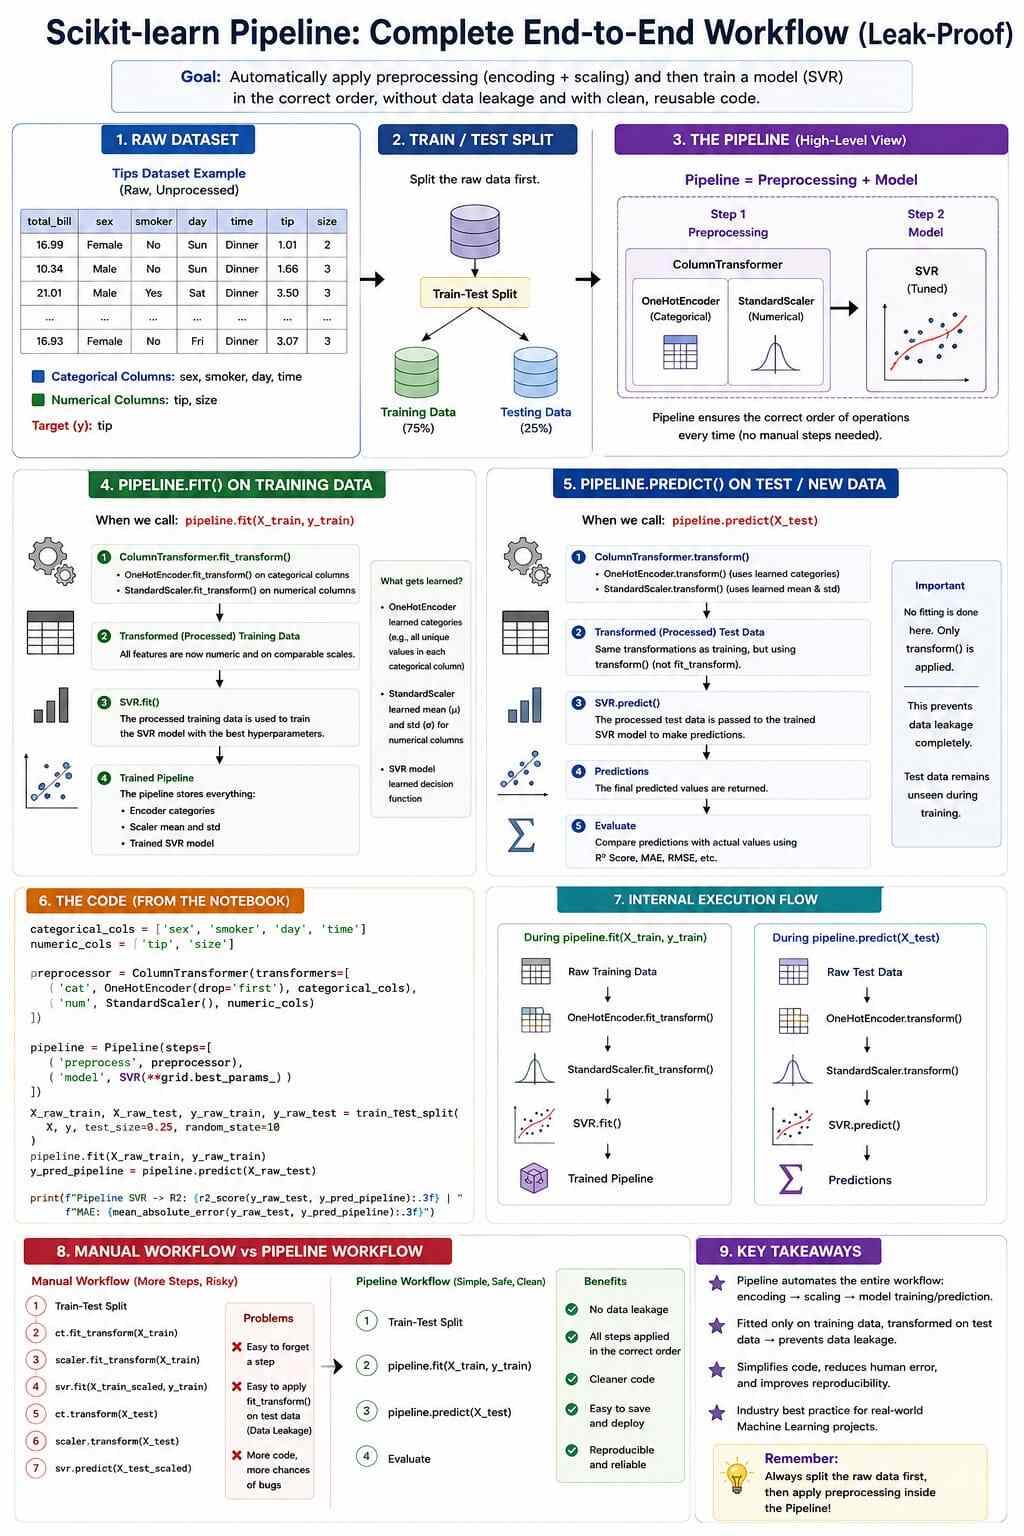